In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Fraud.csv")
print(df.head())
df.info()

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 # 

In [3]:
#Cheaking missing value
missing_values = df.isnull().sum()
print("Missing Values:\n")
print(missing_values)

df.fillna(0,inplace=True) #For Handling Missing Values

Missing Values:

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


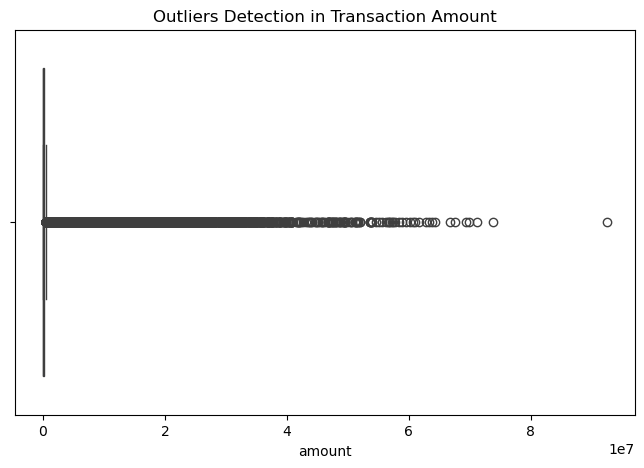

In [4]:
#for Handling Outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=df['amount'])
plt.title("Outliers Detection in Transaction Amount")
plt.show()

Outliers removed successfully


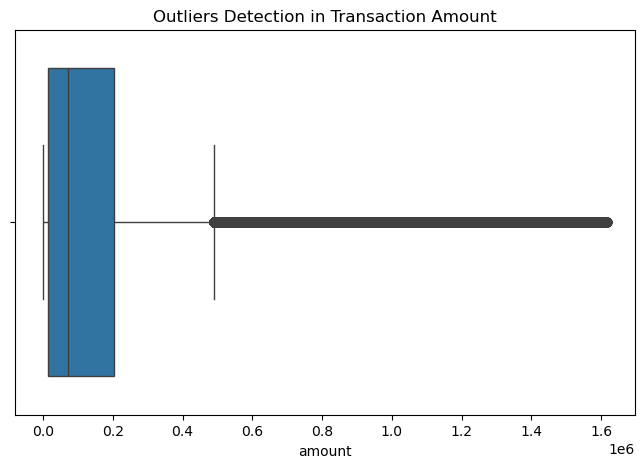

In [5]:
# Removing extreme values
upper_limit = df['amount'].quantile(0.99)
df = df[df['amount'] <= upper_limit]
print("Outliers removed successfully")

plt.figure(figsize=(8,5))
sns.boxplot(x=df['amount'])
plt.title("Outliers Detection in Transaction Amount")
plt.show()

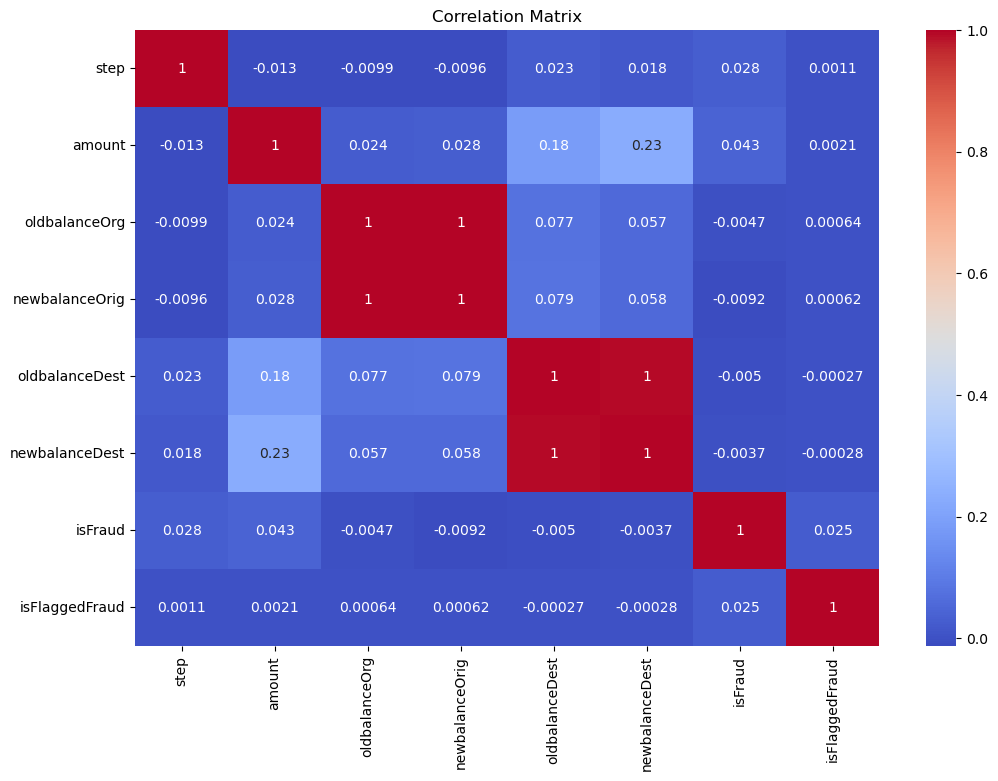

In [6]:
# Checking Multi-collinearity
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [7]:
# Removing highly correlated columns
df.drop(['newbalanceOrig','newbalanceDest'], axis=1, inplace=True)
print("Highly correlated columns removed successfully")
df.head()

Highly correlated columns removed successfully


,step,type,amount,nameOrig,oldbalanceOrg,nameDest,oldbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,M1979787155,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,M2044282225,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,C553264065,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,C38997010,21182.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,M1230701703,0.0,0,0


In [8]:
df.to_csv("CleanFraud.csv", index=False)
print("Clean dataset saved successfully")

Clean dataset saved successfully


In [14]:
# Fraud Detection Model -------------------
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score

print("Preparing Data for Model...\n")

# Remove unnecessary ID columns---------------
df_model = df.drop(['nameOrig','nameDest'], axis=1)

# Convert categorical variable--------
df_model = pd.get_dummies(df_model, columns=['type'], drop_first=True)

print("Categorical variables converted")


# Define Features and Target----------
X = df_model.drop('isFraud', axis=1)
y = df_model['isFraud']



Preparing Data for Model...

Categorical variables converted


In [13]:
print("\nSplitting Dataset...")
# Split dataset----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)




Splitting Dataset...
Training Data Shape: (5039194, 9)
Testing Data Shape: (1259799, 9)


In [17]:
# Build Random Forest Model-----------------------
print("\nTraining Fraud Detection Model...\n")

model = RandomForestClassifier(
    n_estimators=50,       
    max_depth=10,          
    min_samples_split=10, 
    class_weight='balanced',
    random_state=42,
    n_jobs=-1               
)

model.fit(X_train, y_train)

print("Model Training Completed")


# Prediction -----------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]





Training Fraud Detection Model...

Model Training Completed


In [15]:
# Model Performance--------------
print("\nModel Accuracy :", accuracy_score(y_test, y_pred))

print("\nROC AUC Score :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))




Model Accuracy : 0.9669193260194682

ROC AUC Score : 0.9967920006817103

Confusion Matrix

[[1216892   41658]
 [     17    1232]]

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1258550
           1       0.03      0.99      0.06      1249

    accuracy                           0.97   1259799
   macro avg       0.51      0.98      0.52   1259799
weighted avg       1.00      0.97      0.98   1259799



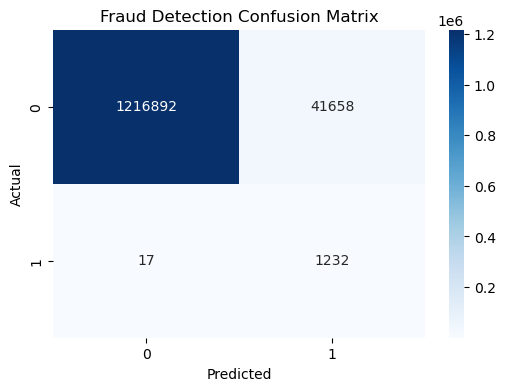

In [16]:
# Confusion Matrix Visualization--------------------------
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Fraud Detection Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




Top Important Features:

oldbalanceOrg     3.176085e-01
amount            1.798370e-01
type_CASH_OUT     1.187303e-01
type_TRANSFER     1.115737e-01
type_PAYMENT      1.020939e-01
oldbalanceDest    9.585864e-02
step              7.337982e-02
type_DEBIT        9.180038e-04
isFlaggedFraud    2.337570e-07
dtype: float64


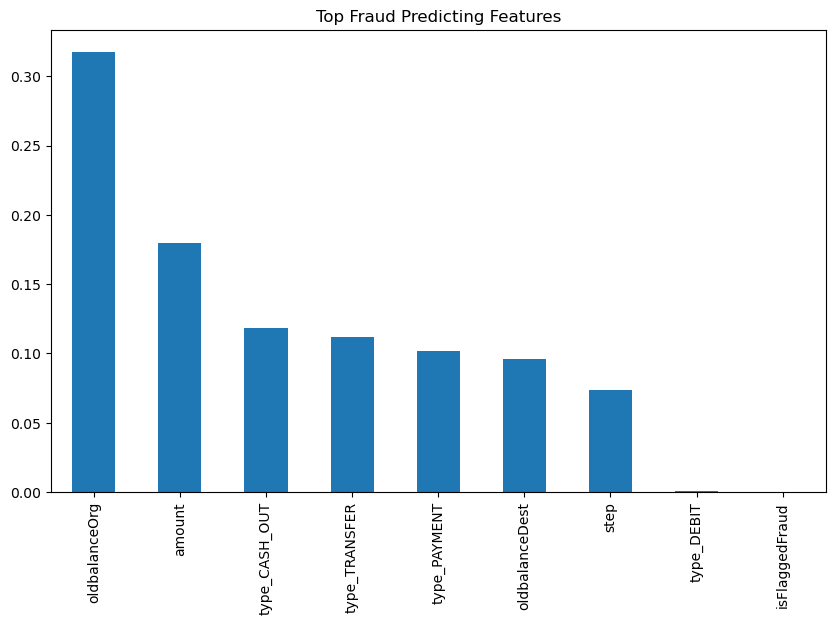


Fraud Detection Model Ready


In [18]:
# Feature Importance----------------
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Important Features:\n")
print(feature_importance.head(10))


plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')

plt.title("Top Fraud Predicting Features")
plt.show()


print("\nFraud Detection Model Ready")
